In [2]:
import os
import importlib
import sys

# for math operations
import numpy as np
import scipy

# for plotting
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# for accelerated computing
import jax
import jax.numpy as jnp
import torch

# Python reachability toolbox
import hj_reachability as hj

# QP tools
# import osqp
from scipy import sparse

In [3]:
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

In [22]:
np.min(obstacle1)

Array(-0.5, dtype=float32)

100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 14.21sim_s/s]
/tmp/ipykernel_1173745/889355960.py:28: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(x, y, value_func.val_grid[:, :, 0].T, levels=[0], colors='black', linewidths=1.5, linestyles='dashed', label='Zero level set')
/tmp/ipykernel_1173745/889355960.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


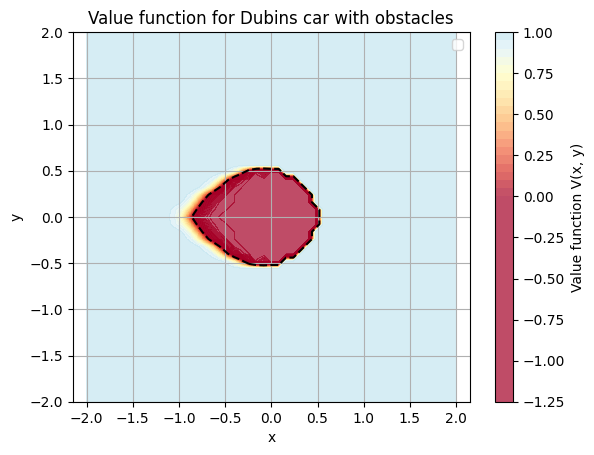

In [26]:
sys.path.append('./value_functions')
import hj_value_function
importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction
from matplotlib import colors

value_func = HJValueFunction(dubins)

# Define failure set
x_c, y_c, radius = 0.0, -1.2, 0.5
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
# failure_lx = jnp.minimum(obstacle1, obstacle2)
# failure_lx = obstacle1

# if obstacle1 > 0, failure_lx = 1, else -1
failure_lx = jnp.where(obstacle1 > 0, 1.0, -1.0)

value_func.compute_V(failure_lx)

# Extract x and y grid for contour plotting
x = value_func.grid.states[..., 0][:, 0, 0]
y = value_func.grid.states[..., 1][0, :, 0]

# Create a custom colormap based on RdYlBu, but set 0 to white

# also plot the zero level set
plt.contour(x, y, value_func.val_grid[:, :, 0].T, levels=[0], colors='black', linewidths=1.5, linestyles='dashed', label='Zero level set')
plt.contourf(x, y, value_func.val_grid[:, :, 0].T, levels=50, cmap='RdYlBu', alpha=0.7)
plt.colorbar(label='Value function V(x, y)')
plt.legend()
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.clim(0, 1.5)  # Adjust color limits for better visibility
plt.title('Value function for Dubins car with obstacles')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



In [735]:
# Simulate (no safety)
N = 100
dt = 0.1
actions = torch.ones(N, 1)*0.1
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1, -0.5, 0])

for k in range(0, N-1):
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)


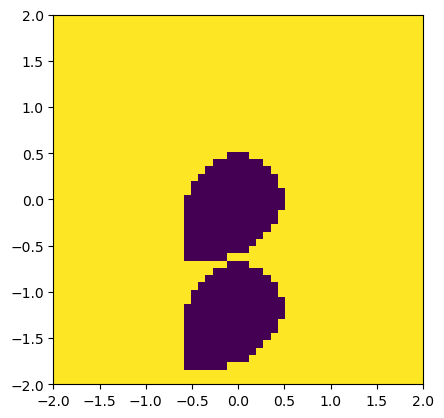

In [736]:
# Animate
import matplotlib.animation as animation

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2])
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

In [737]:
# Simulate with safety filter
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter
import v_func_utils
importlib.reload(v_func_utils)
from v_func_utils import get_spatial_grad, compute_jacobian

N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.5, -0.5, 0])
u_max = 3

# Define function for gradient
vgrad = lambda state: get_spatial_grad(value_func.V, state)

eps = 0.05
dubins.speed = 0.5
goal_state = torch.tensor([1.5, -0.5, 0])
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    # Filter the policy
    actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)
dubins.speed = 0.5


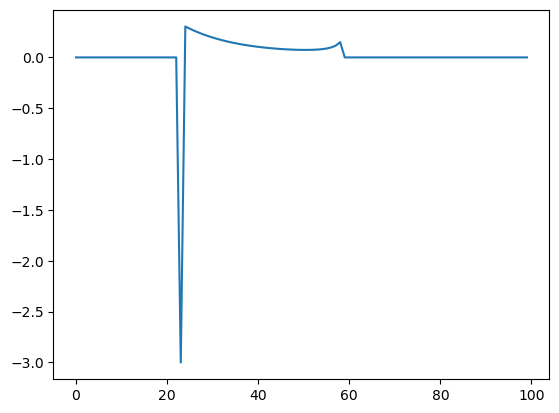

In [738]:
plt.plot(actions)

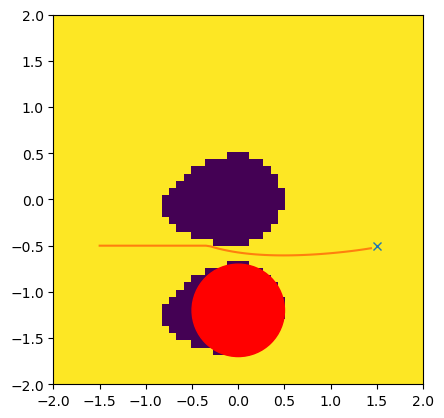

In [739]:
# Animate
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(goal_state[0], goal_state[1], marker='x')
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

(-2.0, 3.0)

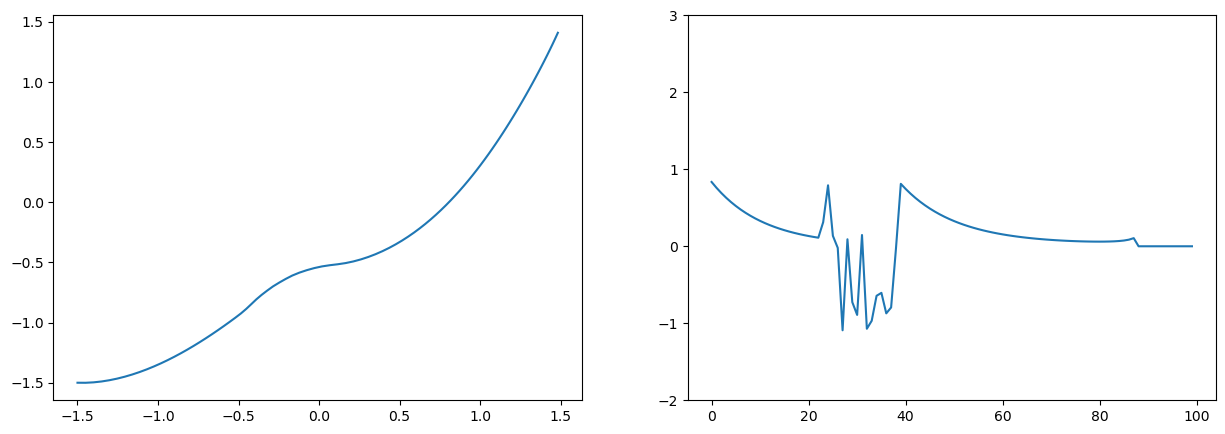

In [740]:
# Simulate with QP
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter, qp_filter

N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.5, -1.5, -0.05])
u_max = 3

# Define function for gradient
vgrad = lambda state: get_spatial_grad(value_func.V, state, eps=0.05)

eps = 0.05
dubins.speed = 0.5
goal_state = torch.tensor([1.5, 1.5, 0])
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    # Filter the policy using a QP
    actions[k, 0], status = qp_filter(actions[k, 0], value_func.V, vgrad, states[k:k+1,:], u_max, 0.03, dubins, dt)

    if status != 'solved': # Fall back to safety filter
        print("infeasible", k)
        actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    # actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(states[:, 0], states[:, 1])
plt.subplot(1, 2, 2)
plt.plot(actions)
plt.ylim(-2, 3)

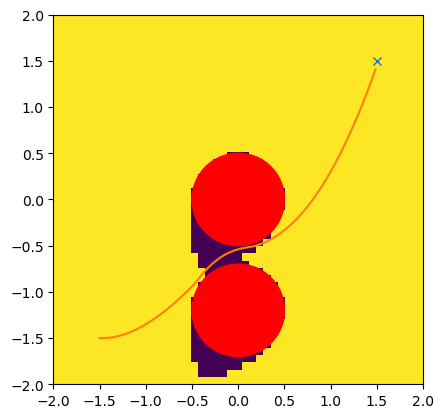

In [741]:
# Animate
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(goal_state[0], goal_state[1], marker='x')
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

(-2.0, 3.0)

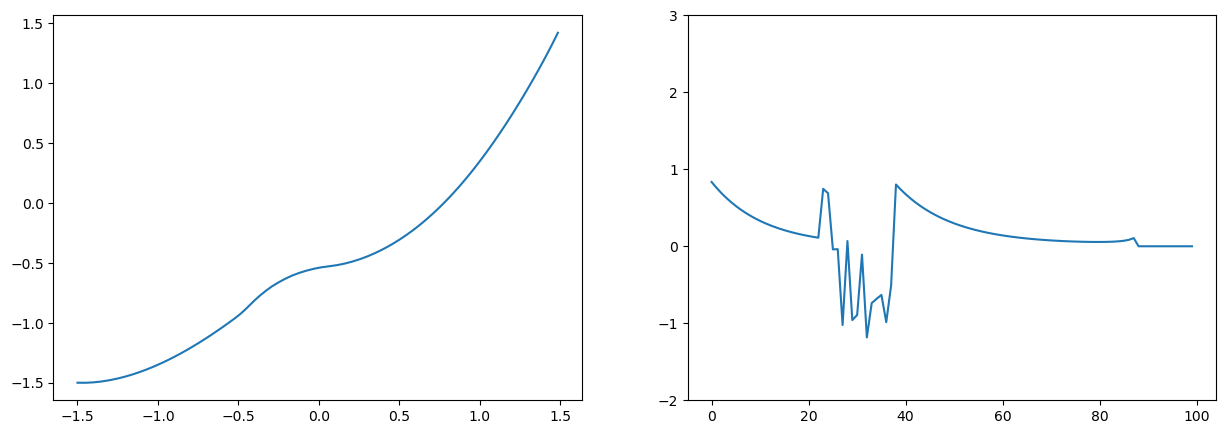

In [742]:
# Simulate with sampling
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter, qp_filter, sampling_filter

N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.5, -1.5, -0.05])
u_max = 3

# Define function for gradient
vgrad = lambda state: get_spatial_grad(value_func.V, state, eps=0.05)

eps = 0.06
dubins.speed = 0.5
goal_state = torch.tensor([1.5, 1.5, 0])
num_samples = 10
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    # Filter the policy using sampling
    actions[k, 0] = sampling_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps, dubins, dt, num_samples)
    
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(states[:, 0], states[:, 1])
plt.subplot(1, 2, 2)
plt.plot(actions)
plt.ylim(-2, 3)

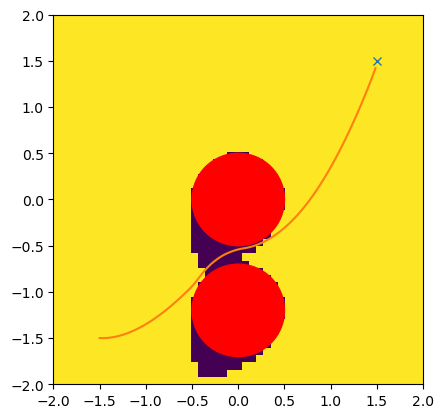

In [743]:
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(goal_state[0], goal_state[1], marker='x')
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF